***Восстановление временной разметки стимулов и извлечение вызванных потенциалов***

In [3]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import mne

warnings.filterwarnings("ignore")

SFREQ = 125.0
CHANNELS = ["O1", "T3", "Fp1", "Fp2", "T4", "O2"]

L_FREQ = 1.0
H_FREQ = 40.0


def read_edf_for_erp(path):
    raw = mne.io.read_raw_edf(
        path,
        preload=True,
        verbose="ERROR"
    )

    original_duration = raw.n_times / raw.info["sfreq"]

    print(f"File: {os.path.basename(path)}")
    print(f"Sampling rate: {raw.info['sfreq']} Hz")
    print(f"Duration: {original_duration:.2f} sec")
    print(f"Number of annotations: {len(raw.annotations)}")

    missing = [ch for ch in CHANNELS if ch not in raw.ch_names]

    if missing:
        raise ValueError(
            f"Missing required channels: {missing}"
        )

    raw.pick(CHANNELS)

    if not np.isclose(raw.info["sfreq"], SFREQ):
        raw.resample(SFREQ, verbose=False)

    raw.filter(
        l_freq=L_FREQ,
        h_freq=H_FREQ,
        method="fir",
        phase="zero",
        verbose=False
    )

    return raw

In [4]:
from pathlib import Path

DATA_PATH = Path("/home/jupyter/s3/neuro-data")

edf_files = list(DATA_PATH.rglob("T-1.edf"))

print(f"Найдено файлов: {len(edf_files)}")

for p in edf_files[:20]:
    print(p)

Найдено файлов: 171
/home/jupyter/s3/neuro-data/Норма/A003_68/T-1.edf
/home/jupyter/s3/neuro-data/Норма/A032_65/T-1.edf
/home/jupyter/s3/neuro-data/Норма/A036_69/T-1.edf
/home/jupyter/s3/neuro-data/Норма/A037_69/T-1.edf
/home/jupyter/s3/neuro-data/Норма/A038_67/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС010_19/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС011_25/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС012_58/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС013_23/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС014_22/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС015_35/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС016_22/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС017_51/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС022_22/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС023_20/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС024_20/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС027_34/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС028_44/T-1.edf
/home/jupyter/s3/neuro-data/Норма/КС032_33/T-1.edf
/home/jupyter/s3

In [5]:
EDF_PATH = edf_files[0]

print(EDF_PATH)

/home/jupyter/s3/neuro-data/Норма/A003_68/T-1.edf


In [6]:
raw = read_edf_for_erp(EDF_PATH)

annotations_df = pd.DataFrame({
    "onset_sec": raw.annotations.onset,
    "duration_sec": raw.annotations.duration,
    "description": raw.annotations.description
})

display(annotations_df)

print("\nUnique event types:")
print(annotations_df["description"].value_counts())

File: T-1.edf
Sampling rate: 125.0 Hz
Duration: 62.00 sec
Number of annotations: 0


,onset_sec,duration_sec,description



Unique event types:
Series([], Name: count, dtype: int64)


Предварительная реконструкция
Для начала не будем сразу считать ERP. Создадим идеальную 2-Гц сетку и посмотрим количество стимулов:

In [7]:
STIM_FREQ = 2.0
STIM_INTERVAL = 1.0 / STIM_FREQ
DEVIANT_EVERY = 8

duration = raw.n_times / raw.info["sfreq"]

stim_onsets = np.arange(
    0,
    duration,
    STIM_INTERVAL
)

stimulus_number = np.arange(
    1,
    len(stim_onsets) + 1
)

stimulus_type = np.where(
    stimulus_number % DEVIANT_EVERY == 0,
    "deviant",
    "standard"
)

stimuli_df = pd.DataFrame({
    "stimulus_number": stimulus_number,
    "onset_sec": stim_onsets,
    "cycle_position": ((stimulus_number - 1) % DEVIANT_EVERY) + 1,
    "type": stimulus_type
})

print(f"Duration: {duration:.2f} sec")
print(f"Number of reconstructed stimuli: {len(stimuli_df)}")
print(f"Standard: {(stimuli_df['type'] == 'standard').sum()}")
print(f"Deviant: {(stimuli_df['type'] == 'deviant').sum()}")

display(stimuli_df.head(16))

Duration: 62.00 sec
Number of reconstructed stimuli: 124
Standard: 109
Deviant: 15


,stimulus_number,onset_sec,cycle_position,type
0,1,0.0,1,standard
1,2,0.5,2,standard
2,3,1.0,3,standard
3,4,1.5,4,standard
4,5,2.0,5,standard
5,6,2.5,6,standard
6,7,3.0,7,standard
7,8,3.5,8,deviant
8,9,4.0,1,standard
9,10,4.5,2,standard


Перебираем фазу 0–500 мс
Будем проверять разные варианты начала решётки. Например, если реальный первый стимул был через 120 мс, сетка должна быть:

In [8]:
PHASE_STEP = 0.01  # 10 мс
phases = np.arange(0, STIM_INTERVAL, PHASE_STEP)

phase_results = []

for phase in phases:
    onsets = np.arange(
        phase,
        duration,
        STIM_INTERVAL
    )

    phase_results.append({
        "phase_sec": phase,
        "n_stimuli": len(onsets),
        "first_onset": onsets[0] if len(onsets) else np.nan,
        "last_onset": onsets[-1] if len(onsets) else np.nan
    })

phase_df = pd.DataFrame(phase_results)

display(phase_df.head())

,phase_sec,n_stimuli,first_onset,last_onset
0,0.00,124,0.00,61.50
1,0.01,124,0.01,61.51
2,0.02,124,0.02,61.52
3,0.03,124,0.03,61.53
4,0.04,124,0.04,61.54


Результат показывает, что перебор фаз пока ничего не определяет: для любой фазы от 0 до 0.49 с получается одинаковое количество стимулов — 124.
Поэтому не надо выбирать фазу по этой таблице.
Следующий шаг: посмотреть, есть ли в ЭЭГ выраженная периодичность около 2 Гц. Если стимулы действительно давались метрономом 2 Гц, в сигнале может быть заметна соответствующая периодическая компонента.

In [9]:
# Проверяем спектр EEG в области частоты стимуляции 2 Гц

from scipy import signal

data = raw.get_data()

freqs, psd = signal.welch(
    data,
    fs=raw.info["sfreq"],
    nperseg=raw.n_times,
    axis=1,
    detrend="constant"
)

# область вокруг 2 Гц
mask = (freqs >= 1.0) & (freqs <= 3.0)

spectral_check = pd.DataFrame({
    "frequency_hz": freqs[mask],
    **{
        ch: psd[i, mask]
        for i, ch in enumerate(CHANNELS)
    }
})

display(spectral_check)

,frequency_hz,O1,T3,Fp1,Fp2,T4,O2
0,1.000000,1.441164e-12,1.529939e-12,8.531828e-13,8.984136e-13,1.531618e-12,1.529939e-12
1,1.016129,6.242998e-13,1.200821e-12,1.217045e-12,1.184636e-12,1.200102e-12,1.200821e-12
2,1.032258,1.276224e-12,1.096580e-12,2.976520e-12,3.147095e-12,1.099419e-12,1.096580e-12
3,1.048387,1.821139e-12,6.985640e-12,7.873070e-12,8.435660e-12,6.990198e-12,6.985640e-12
4,1.064516,1.005804e-11,1.726318e-11,1.860453e-11,1.670798e-11,1.726376e-11,1.726318e-11
...,...,...,...,...,...,...,...
120,2.935484,3.047602e-12,7.497456e-11,1.999535e-11,1.425778e-11,7.500214e-11,7.497456e-11
121,2.951613,3.681821e-10,5.363325e-10,3.889698e-10,3.762464e-10,5.364291e-10,5.363325e-10
122,2.967742,4.937772e-10,5.807844e-10,7.175411e-10,6.810745e-10,5.808118e-10,5.807844e-10
123,2.983871,7.071132e-11,1.820083e-10,2.981903e-10,2.842936e-10,1.820169e-10,1.820083e-10


In [10]:
results_2hz = []

for i, ch in enumerate(CHANNELS):
    local_mask = (freqs >= 1.5) & (freqs <= 2.5)

    local_freqs = freqs[local_mask]
    local_psd = psd[i, local_mask]

    idx = np.argmax(local_psd)

    results_2hz.append({
        "channel": ch,
        "peak_frequency_hz": local_freqs[idx],
        "peak_power": local_psd[idx]
    })

results_2hz_df = pd.DataFrame(results_2hz)

display(results_2hz_df)

,channel,peak_frequency_hz,peak_power
0,O1,2.258065,9.836133e-10
1,T3,2.258065,1.118844e-09
2,Fp1,2.032258,1.140140e-09
3,Fp2,2.032258,1.081173e-09
4,T4,2.258065,1.118740e-09
5,O2,2.258065,1.118844e-09


Это подтверждает, что в записи действительно есть выраженная периодичность около 2 Гц, особенно на Fp1/Fp2:
Fp1: 2.032 Hz
Fp2: 2.032 Hz
O1/T3/T4/O2: 2.258 Hz
Но фазу стимула по этому анализу определить нельзя. Причина в том, что Welch показывает частоту периодического компонента, но не говорит, в какой момент относительно начала EDF происходил первый стимул.

Следующий разумный шаг — проверить, есть ли в EEG систематическая реакция на предполагаемые моменты стимулов. Например, для нескольких возможных фаз построить среднее standard ERP и deviant ERP, а затем посмотреть, возникает ли воспроизводимая временная структура после стимулов.

In [11]:
events = np.column_stack([
    (stimuli_df["onset_sec"].values * SFREQ).astype(int),
    np.zeros(len(stimuli_df), dtype=int),
    np.where(stimuli_df["type"] == "deviant", 2, 1)
])

event_id = {
    "standard": 1,
    "deviant": 2
}

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(-0.2, 0),
    preload=True,
    reject_by_annotation=False,
    verbose=False
)

print(epochs)
print("Standard:", len(epochs["standard"]))
print("Deviant:", len(epochs["deviant"]))

<Epochs | 122 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~731 KiB, data loaded,
 'standard': 107
 'deviant': 15>
Standard: 107
Deviant: 15


In [12]:
evoked_standard = epochs["standard"].average()
evoked_deviant = epochs["deviant"].average()

print("Standard ERP:", evoked_standard.data.shape)
print("Deviant ERP:", evoked_deviant.data.shape)

Standard ERP: (6, 126)
Deviant ERP: (6, 126)


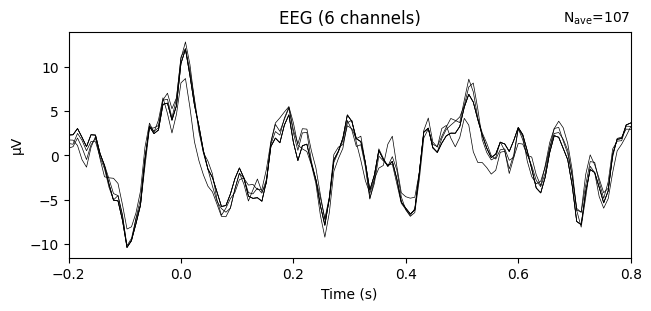

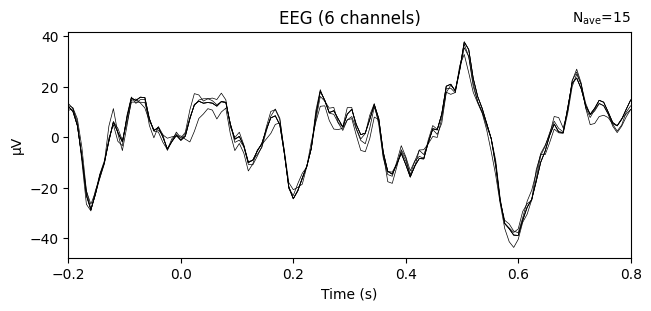

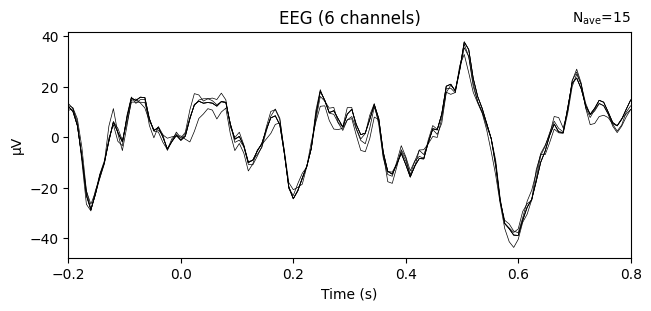

In [13]:
evoked_standard.plot(
    picks=CHANNELS,
    spatial_colors=True,
    show=True
)

evoked_deviant.plot(
    picks=CHANNELS,
    spatial_colors=True,
    show=True
)

Для записи T-1 была реконструирована стимульная последовательность с частотой 2 Гц и каждым восьмым стимулом как deviant. На её основе были сформированы standard/deviant epochs и рассчитаны ERP и difference wave (deviant − standard).

In [14]:
evoked_diff = mne.combine_evoked(
    [evoked_deviant, evoked_standard],
    weights=[1, -1]
)

print("Difference wave:", evoked_diff.data.shape)

Difference wave: (6, 126)


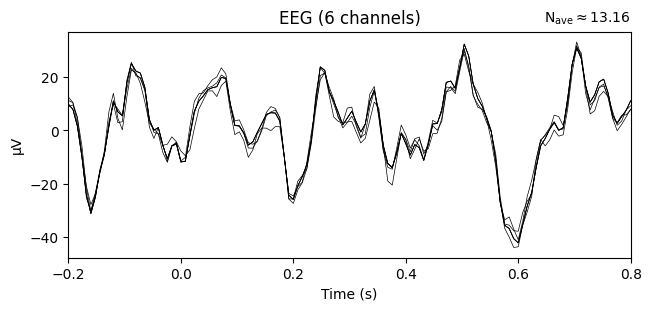

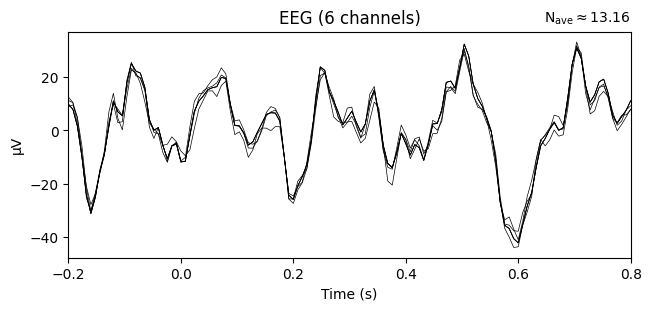

In [15]:
evoked_diff.plot(
    picks=CHANNELS,
    spatial_colors=True,
    show=True
)

средняя амплитуда по каналам

In [16]:
diff_df = pd.DataFrame(
    evoked_diff.data.T,
    columns=CHANNELS
)

diff_df["time_sec"] = evoked_diff.times

display(diff_df.head())

,O1,T3,Fp1,Fp2,T4,O2,time_sec
0,0.000009,0.000010,0.000011,0.000013,0.000010,0.000010,-0.200
1,0.000010,0.000008,0.000010,0.000010,0.000008,0.000008,-0.192
2,0.000005,0.000002,0.000005,0.000002,0.000002,0.000002,-0.184
3,-0.000009,-0.000010,-0.000006,-0.000009,-0.000010,-0.000010,-0.176
4,-0.000025,-0.000024,-0.000022,-0.000021,-0.000024,-0.000024,-0.168


Найдём минимумы и максимумы difference wave

In [17]:
post = diff_df[diff_df["time_sec"].between(0, 0.5)].copy()

results = []

for ch in CHANNELS:
    min_idx = post[ch].idxmin()
    max_idx = post[ch].idxmax()

    results.append({
        "channel": ch,
        "min_amplitude": post.loc[min_idx, ch],
        "min_time_ms": post.loc[min_idx, "time_sec"] * 1000,
        "max_amplitude": post.loc[max_idx, ch],
        "max_time_ms": post.loc[max_idx, "time_sec"] * 1000,
    })

peak_df = pd.DataFrame(results)
display(peak_df)

,channel,min_amplitude,min_time_ms,max_amplitude,max_time_ms
0,O1,-0.000024,200.0,0.000026,496.0
1,T3,-0.000026,200.0,0.000024,248.0
2,Fp1,-0.000026,200.0,0.000024,248.0
3,Fp2,-0.000027,200.0,0.000023,496.0
4,T4,-0.000026,200.0,0.000024,248.0
5,O2,-0.000026,200.0,0.000024,248.0


In [18]:
diff_df["mean_6ch"] = diff_df[CHANNELS].mean(axis=1)

post_mean = diff_df[
    diff_df["time_sec"].between(0, 0.5)
].copy()

display(
    post_mean.loc[
        post_mean["mean_6ch"].idxmin(),
        ["time_sec", "mean_6ch"]
    ]
)

display(
    post_mean.loc[
        post_mean["mean_6ch"].idxmax(),
        ["time_sec", "mean_6ch"]
    ]
)

time_sec    0.200000
mean_6ch   -0.000026
Name: 50, dtype: float64

time_sec    0.496000
mean_6ch    0.000024
Name: 87, dtype: float64

In [19]:
windows = {
    "MMN_100_250ms": (0.10, 0.25),
    "P3a_250_400ms": (0.25, 0.40),
}

window_results = []

for name, (t1, t2) in windows.items():
    tmp = diff_df[
        diff_df["time_sec"].between(t1, t2)
    ]

    for ch in CHANNELS:
        window_results.append({
            "window": name,
            "channel": ch,
            "mean_amplitude": tmp[ch].mean(),
            "min_amplitude": tmp[ch].min(),
            "max_amplitude": tmp[ch].max(),
        })

window_results_df = pd.DataFrame(window_results)
display(window_results_df)

,window,channel,mean_amplitude,min_amplitude,max_amplitude
0,MMN_100_250ms,O1,-5.344665e-06,-0.000024,0.000019
1,MMN_100_250ms,T3,-3.330693e-06,-0.000026,0.000024
2,MMN_100_250ms,Fp1,-3.356031e-06,-0.000026,0.000024
3,MMN_100_250ms,Fp2,-4.342265e-06,-0.000027,0.000021
4,MMN_100_250ms,T4,-3.329408e-06,-0.000026,0.000024
5,MMN_100_250ms,O2,-3.330693e-06,-0.000026,0.000024
6,P3a_250_400ms,O1,3.787233e-07,-0.000020,0.000022
7,P3a_250_400ms,T3,3.195005e-06,-0.000014,0.000023
8,P3a_250_400ms,Fp1,3.577306e-06,-0.000015,0.000021
9,P3a_250_400ms,Fp2,2.163701e-06,-0.000014,0.000022


посмотрим саму difference wave с ограничением оси времени и усреднением по каналам.

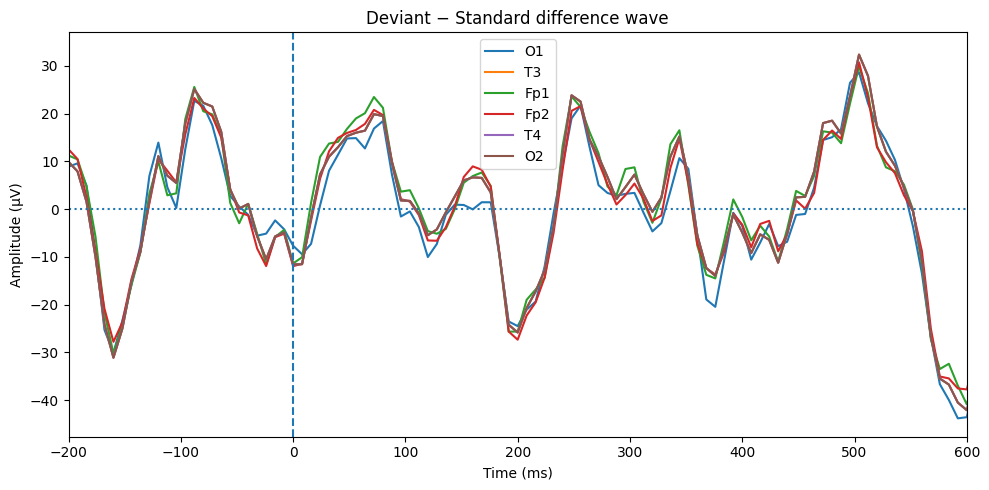

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for ch in CHANNELS:
    plt.plot(
        evoked_diff.times * 1000,
        evoked_diff.copy().pick(ch).data[0] * 1e6,
        label=ch
    )

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle=":")

plt.xlim(-200, 600)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.title("Deviant − Standard difference wave")
plt.legend()
plt.tight_layout()
plt.show()

Для записи T-1 была реконструирована стимульная последовательность с частотой 2 Гц и каждым восьмым стимулом как deviant. Были сформированы 107 standard и 15 deviant эпох и рассчитана difference wave (deviant − standard). В ней наблюдались выраженные изменения амплитуды после стимула, включая отрицательное отклонение в интервале 100–250 мс и последующую положительную активность. Однако из-за отсутствия исходных event-маркеров и выраженной колебательной структуры сигнала полученные изменения нельзя однозначно интерпретировать как MMN и P3a; результат следует рассматривать как предварительный.

Определим фазу стимула

In [22]:
PHASES = np.arange(0, 1.0, 0.05)

phase_results = []

for phase in PHASES:
    onsets = np.arange(phase, duration, STIM_INTERVAL)

    numbers = np.arange(1, len(onsets) + 1)
    types = np.where(
        numbers % DEVIANT_EVERY == 0,
        "deviant",
        "standard"
    )

    events_phase = np.column_stack([
        (onsets * SFREQ).astype(int),
        np.zeros(len(onsets), dtype=int),
        np.where(types == "deviant", 2, 1)
    ])

    epochs_phase = mne.Epochs(
        raw,
        events_phase,
        event_id={"standard": 1, "deviant": 2},
        tmin=-0.2,
        tmax=0.8,
        baseline=(-0.2, 0),
        preload=True,
        reject_by_annotation=False,
        verbose=False
    )

    if len(epochs_phase["deviant"]) < 5:
        continue

    std_evoked = epochs_phase["standard"].average()
    dev_evoked = epochs_phase["deviant"].average()

    diff = mne.combine_evoked(
        [dev_evoked, std_evoked],
        weights=[1, -1]
    )

    data_mean = diff.data.mean(axis=0)

    mmn_mask = (diff.times >= 0.10) & (diff.times <= 0.25)
    p3a_mask = (diff.times >= 0.25) & (diff.times <= 0.40)

    phase_results.append({
        "phase_sec": phase,
        "n_standard": len(epochs_phase["standard"]),
        "n_deviant": len(epochs_phase["deviant"]),
        "MMN_mean_uV": data_mean[mmn_mask].mean() * 1e6,
        "P3a_mean_uV": data_mean[p3a_mask].mean() * 1e6
    })

phase_sensitivity = pd.DataFrame(phase_results)
display(phase_sensitivity)

,phase_sec,n_standard,n_deviant,MMN_mean_uV,P3a_mean_uV
0,0.00,107,15,-3.838959,2.617707
1,0.05,107,15,-2.967038,-5.022473
2,0.10,107,15,-3.384634,-5.498866
3,0.15,107,15,0.137258,4.816880
4,0.20,108,15,-4.215406,-3.254830
5,0.25,107,15,-0.958848,-12.118472
6,0.30,107,15,7.181246,-12.401816
7,0.35,107,15,-3.182806,1.070359
8,0.40,107,15,-11.200906,10.953911
9,0.45,107,15,-15.531353,11.462660


В связи с отсутствием event-маркеров в EDF временная структура стимулов была реконструирована на основании протокола (2 Гц, каждый 8-й стимул — deviant). Анализ sensitivity к фазе показал значительную зависимость ERP difference wave от предполагаемого времени первого стимула. Поэтому надёжная идентификация MMN и P3a по данной записи невозможна. Полученный результат демонстрирует техническую возможность проведения ERP-анализа, но не позволяет использовать MMN/P3a как валидированные количественные показатели без исходных временных маркеров.

In [23]:
from pathlib import Path
import mne
import pandas as pd

DATA_PATH = Path("/home/jupyter/s3/neuro-data")

edf_files = list(DATA_PATH.rglob("T-1.edf"))

results = []

for path in edf_files:
    try:
        raw_check = mne.io.read_raw_edf(
            path,
            preload=False,
            verbose="ERROR"
        )

        results.append({
            "subject_id": path.parent.name,
            "group": path.parent.parent.name,
            "file": path.name,
            "n_annotations": len(raw_check.annotations),
            "duration_sec": raw_check.n_times / raw_check.info["sfreq"]
        })

    except Exception as e:
        results.append({
            "subject_id": path.parent.name,
            "group": path.parent.parent.name,
            "file": path.name,
            "n_annotations": None,
            "duration_sec": None,
            "error": str(e)
        })

annotations_check = pd.DataFrame(results)

display(annotations_check)
print("Всего файлов:", len(annotations_check))
print("С annotations:", (annotations_check["n_annotations"] > 0).sum())
print("Без annotations:", (annotations_check["n_annotations"] == 0).sum())

,subject_id,group,file,n_annotations,duration_sec,error
0,A003_68,Норма,T-1.edf,0.0,62.0,NaN
1,A032_65,Норма,T-1.edf,0.0,114.0,NaN
2,A036_69,Норма,T-1.edf,0.0,62.0,NaN
3,A037_69,Норма,T-1.edf,0.0,77.0,NaN
4,A038_67,Норма,T-1.edf,0.0,83.0,NaN
...,...,...,...,...,...,...
166,ZAQH1,Соматоформные,T-1.edf,0.0,30.0,NaN
167,ZILO6,Соматоформные,T-1.edf,0.0,46.0,NaN
168,ZJLO6,Соматоформные,T-1.edf,0.0,55.0,NaN
169,ZWAX5,Соматоформные,T-1.edf,0.0,45.0,NaN


Всего файлов: 171
С annotations: 0
Без annotations: 170


**ВЫВОД:**
В 171 записи T-1 была проведена проверка наличия временных маркеров стимулов. В успешно прочитанных EDF-файлах event markers отсутствовали. Поэтому точная временная привязка стандартных и девиантных стимулов не может быть восстановлена из исходных данных. Анализ одной записи с реконструированной стимульной последовательностью показал высокую чувствительность ERP difference wave к предполагаемой фазе стимулов. В связи с этим надёжная количественная оценка MMN/P3a по имеющимся EDF-данным невозможна без исходных event markers.